<table style="width: 100%;">
    <tr style="background-color: transparent;"><td>
        <img src="https://data-88e.github.io/assets/images/blue_text.png" width="250px" style="margin-left: 0;" />
    </td><td>
        <p style="text-align: right; font-size: 10pt;"><strong>Economic Models</strong>, Fall 2025<br>
            Dr. Eric Van Dusen <br>
        Kidong Kim</p></td></tr>
</table>


# Market Equilibrium, Surplus, and Tax Incidence

This notebook explores:
- **Market equilibrium** where supply and demand intersect  
- **Consumer and producer surplus**  
- **Comparative statics** (shifts in supply and demand)  
- **Elasticity and tax incidence** (who bears the burden of a tax)  



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown





## 1. Market Equilibrium and Surplus

We start with linear demand and supply functions:

- Demand: $P = a - bQ$
- Supply: $P = c + dQ$

Equilibrium is where these two curves intersect.

**Baseline parameters for a,b,c,d are 20, 0.5, 2, 0.2 **

so 
 - $p_demand=20 - 0.5Q$ 
- $p_supply=2 + 0.2Q$


In [8]:
# Baseline parameters
BASE_A, BASE_B, BASE_C, BASE_D = 20, 0.5, 2, 0.2

In [9]:

def demand(Q, a, b): return a - b*Q
def supply(Q, c, d): return c + d*Q

def equilibrium(a, b, c, d):
    Q_star = (a - c) / (b + d)
    P_star = a - b*Q_star
    return Q_star, P_star

# Example with baseline params
Q_star, P_star = equilibrium(BASE_A, BASE_B, BASE_C, BASE_D)
Q_star, P_star


(25.714285714285715, 7.142857142857142)


### Visualizing Equilibrium and Consumer Surplus

The shaded area below the demand curve and above the equilibrium price represents **Consumer Surplus**.


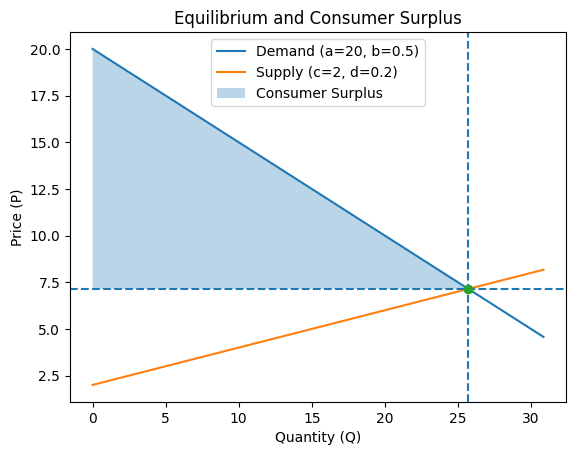

Equilibrium Q*=25.71, P*=7.14, Consumer Surplus=165.31


In [10]:

def plot_equilibrium(a=20, b=0.5, c=2, d=0.2):
    Q_star, P_star = equilibrium(a,b,c,d)
    Q = np.linspace(0, max(30,1.2*Q_star), 400)
    Pd, Ps = demand(Q,a,b), supply(Q,c,d)
    
    CS = 0.5 * Q_star * (a - P_star)
    
    fig, ax = plt.subplots()
    ax.plot(Q, Pd, label=f"Demand (a={a}, b={b})")
    ax.plot(Q, Ps, label=f"Supply (c={c}, d={d})")
    ax.fill_between(np.linspace(0,Q_star,200), P_star, demand(np.linspace(0,Q_star,200),a,b), 
                    alpha=0.3, label="Consumer Surplus")
    
    ax.axvline(Q_star, ls="--"); ax.axhline(P_star, ls="--"); ax.plot([Q_star],[P_star],"o")
    ax.set_xlabel("Quantity (Q)"); ax.set_ylabel("Price (P)")
    ax.set_title("Equilibrium and Consumer Surplus")
    ax.legend(); plt.show()
    
    print(f"Equilibrium Q*={Q_star:.2f}, P*={P_star:.2f}, Consumer Surplus={CS:.2f}")

plot_equilibrium()



## 2. Comparative Statics with Sliders

We can explore how shifting demand and supply changes equilibrium outcomes and surplus.


In [11]:

def comparative_statics(a=20,b=0.5,c=2,d=0.2,demand_shift=0,supply_shift=0):
    A, C = a+demand_shift, c+supply_shift
    Q_star, P_star = equilibrium(A,b,C,d)
    CS = 0.5*Q_star*(A-P_star)
    
    Q = np.linspace(0, max(30,1.2*Q_star), 400)
    Pd, Ps = demand(Q,A,b), supply(Q,C,d)
    
    fig, ax = plt.subplots()
    ax.plot(Q,Pd,label=f"Demand (a={A}, b={b})")
    ax.plot(Q,Ps,label=f"Supply (c={C}, d={d})")
    ax.fill_between(np.linspace(0,Q_star,200),P_star,demand(np.linspace(0,Q_star,200),A,b),alpha=0.3)
    
    ax.axvline(Q_star,ls="--"); ax.axhline(P_star,ls="--"); ax.plot([Q_star],[P_star],"o")
    ax.set_xlabel("Q"); ax.set_ylabel("P"); ax.set_title("Comparative Statics"); ax.legend(); plt.show()
    
    print(f"Equilibrium Q*={Q_star:.2f}, P*={P_star:.2f}, CS={CS:.2f}")

interact(
    comparative_statics,
    a=FloatSlider(value=20,min=5,max=40,step=0.5,description="a (Demand intercept)"),
    b=FloatSlider(value=0.5,min=0.05,max=1.5,step=0.05,description="b (Demand slope)"),
    c=FloatSlider(value=2,min=0,max=20,step=0.5,description="c (Supply intercept)"),
    d=FloatSlider(value=0.2,min=0.05,max=1.0,step=0.05,description="d (Supply slope)"),
    demand_shift=FloatSlider(value=0,min=-10,max=10,step=0.5,description="Demand shift"),
    supply_shift=FloatSlider(value=0,min=-10,max=10,step=0.5,description="Supply shift"),
);


interactive(children=(FloatSlider(value=20.0, description='a (Demand intercept)', max=40.0, min=5.0, step=0.5)…


## 3. Tax Incidence and Elasticity

We now add a per-unit tax `t`.  
- The supply curve shifts up by `t`.  
- We shade both **consumer surplus (blue)** and **producer surplus (green)**, as well as **tax revenue (orange)**.  

We can compare how outcomes differ under **inelastic vs elastic demand**.


In [26]:
def tax_incidence(a=20, b=0.5, c=2, d=0.2, t=4.0):
    # Pre-tax equilibrium
    Q0 = (a - c) / (b + d)
    P0 = a - b * Q0

    # Post-tax equilibrium
    Q1 = (a - (c + t)) / (b + d)
    Pb = a - b * Q1       # buyer price after tax
    Ps = Pb - t           # seller price after tax

    # Fixed axis ranges for better slope comparison
    Q_max = 40
    P_max = max(a, c + t) + 20
    Q = np.linspace(0, Q_max, 400)

    # Curves
    Pd = a - b * Q
    Ps0 = c + d * Q
    Ps1 = (c + t) + d * Q

    fig, ax = plt.subplots()
    ax.plot(Q, Pd, label="Demand")
    ax.plot(Q, Ps0, label="Supply")
    ax.plot(Q, Ps1, label="Supply + tax")

    # Equilibria
    ax.plot([Q0], [P0], "o", label="Pre-tax Eq")
    ax.plot([Q1], [Pb], "o", label="Post-tax Eq")

    # Shade post-tax CS and PS
    Qcs = np.linspace(0, Q1, 200)
    ax.fill_between(Qcs, Pb, a - b * Qcs, alpha=0.3, color="blue", label="Consumer Surplus")
    ax.fill_between(Qcs, c + d * Qcs, Ps, alpha=0.3, color="green", label="Producer Surplus")

    # Government revenue rectangle
    ax.fill_between([0, Q1], [Ps], [Pb], alpha=0.3, color="orange", label="Tax revenue")

    # Fix axis limits so slope changes are visible
    ax.set_xlim(0, Q_max)
    ax.set_ylim(0, P_max)

    ax.set_xlabel("Quantity (Q)")
    ax.set_ylabel("Price (P)")
    ax.set_title("Tax Incidence with Fixed Axes")
    ax.legend(loc="best")
    plt.show()

    print(f"After tax: Q={Q1:.2f}, Pb={Pb:.2f}, Ps={Ps:.2f}")

# Interactive controls
interact(
    tax_incidence,
    a=FloatSlider(value=20, min=5, max=40, step=0.5, description="a (Demand intercept)"),
    b=FloatSlider(value=0.5, min=0.05, max=1.5, step=0.05, description="b (Demand slope)"),
    c=FloatSlider(value=2, min=0, max=20, step=0.5, description="c (Supply intercept)"),
    d=FloatSlider(value=0.2, min=0.05, max=1.0, step=0.05, description="d (Supply slope)"),
    t=FloatSlider(value=4.0, min=0, max=15, step=0.5, description="Tax"),
);

interactive(children=(FloatSlider(value=20.0, description='a (Demand intercept)', max=40.0, min=5.0, step=0.5)…

## 4. Policy Analysis and tracking changes in Surplus

- Finally we want to track how changes in a tax or subsidy change consumer and producer surplus.
- this is important for welfare analysis and understanding the effects of government intervention in markets.

In [24]:
def tax_incidence(a=20, b=0.5, c=2, d=0.2, t=4.0):
    # Pre-tax equilibrium
    Q0 = (a - c) / (b + d)
    P0 = a - b * Q0
    CS0 = 0.5 * Q0 * (a - P0)
    PS0 = 0.5 * Q0 * (P0 - c)

    # Post-tax equilibrium
    Q1 = (a - (c + t)) / (b + d)
    Pb = a - b * Q1        # buyer price
    Ps = Pb - t            # seller price
    CS1 = 0.5 * Q1 * (a - Pb)
    PS1 = 0.5 * Q1 * (Ps - c)
    TR = t * Q1
    DWL = (CS0 + PS0) - (CS1 + PS1 + TR)

    # Fix axis ranges for better comparison
    Q_max = 40
    P_max = max(a, c + t) + 20  # ensure intercepts fit
    Q = np.linspace(0, Q_max, 400)

    Pd = a - b * Q
    Ps0 = c + d * Q
    Ps1 = (c + t) + d * Q

    fig, ax = plt.subplots()
    ax.plot(Q, Pd, label="Demand")
    ax.plot(Q, Ps0, label="Supply")
    ax.plot(Q, Ps1, label="Supply + tax")

    # Equilibria
    ax.plot([Q0], [P0], "o", label="Pre-tax Eq")
    ax.plot([Q1], [Pb], "o", label="Post-tax Eq")

    # Shade pre-tax CS & PS
    Qcs = np.linspace(0, Q0, 200)
    ax.fill_between(Qcs, P0, a - b * Qcs, alpha=0.2, color="blue", label="CS pre-tax")
    ax.fill_between(Qcs, c + d * Qcs, P0, alpha=0.2, color="green", label="PS pre-tax")

    # Shade post-tax CS & PS
    Qcs1 = np.linspace(0, Q1, 200)
    ax.fill_between(Qcs1, Pb, a - b * Qcs1, alpha=0.4, color="blue", label="CS post-tax")
    ax.fill_between(Qcs1, c + d * Qcs1, Ps, alpha=0.4, color="green", label="PS post-tax")

    # Government revenue rectangle
    ax.fill_between([0, Q1], [Ps], [Pb], alpha=0.3, color="orange", label="Tax revenue")

    # Fixed axis limits so slope changes are visible
    ax.set_xlim(0, Q_max)
    ax.set_ylim(0, P_max)

    ax.set_xlabel("Quantity (Q)")
    ax.set_ylabel("Price (P)")
    ax.set_title("Tax Incidence and Surplus")
    ax.legend(loc="best")
    plt.show()

    # Print outcomes
    print(f"Pre-tax: Q={Q0:.2f}, P={P0:.2f}, CS={CS0:.2f}, PS={PS0:.2f}")
    print(f"Post-tax: Q={Q1:.2f}, Pb={Pb:.2f}, Ps={Ps:.2f}, CS={CS1:.2f}, PS={PS1:.2f}, TR={TR:.2f}")
    print(f"Deadweight Loss ≈ {DWL:.2f}")
    print(f"Change in CS={CS1-CS0:+.2f}, Change in PS={PS1-PS0:+.2f}")

In [25]:

interact(
    tax_incidence,
    a=FloatSlider(value=20,min=5,max=40,step=0.5,description="a (Demand intercept)"),
    b=FloatSlider(value=0.5,min=0.05,max=1.5,step=0.05,description="b (Demand slope)"),
    c=FloatSlider(value=2,min=0,max=20,step=0.5,description="c (Supply intercept)"),
    d=FloatSlider(value=0.2,min=0.05,max=1.0,step=0.05,description="d (Supply slope)"),
    t=FloatSlider(value=4.0,min=0,max=15,step=0.5,description="Tax t"),
);

interactive(children=(FloatSlider(value=20.0, description='a (Demand intercept)', max=40.0, min=5.0, step=0.5)…